# Project 6 - Code Breaking with Statistical Physics

#####     Authors: Alex Bell, Lucy Burchell, Hong Chen, Bingxiang Hu, Zoe Morton.

## Core Question #1

> 1\. (**core**) In the first message, the cipher is simply a cyclic
> shift of the 27 characters. E.g. a shift of 2 would map *A →C*, *B
> →D*, *. . .* , *Y* →space, *Z →A*, space *→B*. Find the shift and
> decode the message. One simple approach is to try all possibilities
> and check by hand which one produces readable text.

#### Coded Message:

> 1\. GPKZFER JRSER EKWIGIWKWVRZ YZRCWMWCRSEVRYWEWISCRGLIGFJWRGIFYISDD EYRCSEYLSYWRGPKZFEJRVWJ YERGZ CFJFGZPRWDGZSJ QWJRUFVWRIWSVST C KPRN KZR KJREFKSTCWRLJWRFXRJ YE X USEKR EVWEKSK FER KJRCSEYLSYWRUFEJKILUKJRSEVRFTAWUKRFI WEKWVRSGGIFSUZRS DRKFRZWCGRGIFYISDDWIJRNI KWRUCWSIRCFY USCRUFVWRXFIRJDSCCRSEVRCSIYWRJUSCWRGIFAWUKJ

#### Method:

We first started out by identifying the most frequently used character within the coded message. We quickly determinded this to be 'R' which, once compared to the 27 characters available, must be 'space'. From here, we calculated the cyclic shift (from the coded message to our list of characters - so from 'R' to 'space') which was 9.

We then translated this method into python:

In [27]:
#CREATE A PATH TO EASILY REFERENCE CODED MESSAGES
import nbformat

notebook_path = 'CodedMessages.ipynb'
cell_index = 0

try:
    with open(notebook_path, 'r', encoding = 'utf-8') as f:
        nb = nbformat.read(f, as_version = 4)

    cell = nb.cells[cell_index]

    coded_message_01 = cell.source

except FileNotFoundError:
    print('Could not find file.')
except IndexError:
    print('Indexing Error.')

#CHECK THE CORRECT CODED MESSAGE WAS RECEIVED
print(coded_message_01)

GPKZFER JRSER EKWIGIWKWVRZ YZRCWMWCRSEVRYWEWISCRGLIGFJWRGIFYISDD EYRCSEYLSYWRGPKZFEJRVWJ YERGZ CFJFGZPRWDGZSJ QWJRUFVWRIWSVST C KPRN KZR KJREFKSTCWRLJWRFXRJ YE X USEKR EVWEKSK FER KJRCSEYLSYWRUFEJKILUKJRSEVRFTAWUKRFI WEKWVRSGGIFSUZRS DRKFRZWCGRGIFYISDDWIJRNI KWRUCWSIRCFY USCRUFVWRXFIRJDSCCRSEVRCSIYWRJUSCWRGIFAWUKJ


In [28]:
#DEFINE OUR LIST OF ALL 27 CHARACTERS
character_list = ["A" , "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "Z", " "]

In [29]:
#DEFINE A CYCLIC SHIFT FUNCTION
shift = 9

def cyclic_shift(cipher_letter):

    cipher_index = character_list.index(cipher_letter)
    character_index = (cipher_index + shift) % 27
    
    decipher_letter = character_list[character_index]

    return decipher_letter

#TEST THIS FUNCTION WORKS
cyclic_shift('R')

' '

In [30]:
#Purely for satisfaction, here is a list of all the cyclic shifts:
for letter in character_list:
    print(f'{letter} --> {cyclic_shift(letter)}')

A --> J
B --> K
C --> L
D --> M
E --> N
F --> O
G --> P
H --> Q
I --> R
J --> S
K --> T
L --> U
M --> V
N --> W
O --> X
P --> Y
Q --> Z
R -->  
S --> A
T --> B
U --> C
V --> D
W --> E
X --> F
Y --> G
Z --> H
  --> I


In [31]:
#DEFINE A FUNCTION TO DECODE THE WHOLE MESSAGE
def message_decoder(coded_message):

    deciphered_message = ''

    for i in range(0, len(coded_message),):
        
        current_letter = coded_message[i]

        deciphered_letter = cyclic_shift(current_letter)

        deciphered_message += deciphered_letter

    return deciphered_message
    
#TEST FUNCTION WORKS
message_decoder(coded_message_01)

'PYTHON IS AN INTERPRETED HIGH LEVEL AND GENERAL PURPOSE PROGRAMMING LANGUAGE PYTHONS DESIGN PHILOSOPHY EMPHASIZES CODE READABILITY WITH ITS NOTABLE USE OF SIGNIFICANT INDENTATION ITS LANGUAGE CONSTRUCTS AND OBJECT ORIENTED APPROACH AIM TO HELP PROGRAMMERS WRITE CLEAR LOGICAL CODE FOR SMALL AND LARGE SCALE PROJECTS'

The fully decoded message (written with correct punctuation):

>Python is an interpreted, high level, and general purpose programming language. Python's design philosophy EMP hasizes code readability with it's notable use of significant indentation. Its langauge contructs and object-oriented approach aim to help programmers write clear, logical code for small and large-scale projects.

## Core Question #2

>2\. (**core**) The other messages each use an arbitrary permutation of the characters, so trying
all the possibilities is no longer practical. Instead we will make use of statistical properties
of text. In preparation for this, find a large body of English text (the larger the better) to
download and analyse. Replace all lower case letters with upper case, and find a way to
get rid of extra characters. One simple approach is to replace every character that is not a
capital letter or a space with a space, and then replace multiple consecutive spaces with a
single space. More nuanced schemes are possible - for instance, apostrophes and hyphens
could be treated differently.
>
>For example, the following code will download the text of the novel Moby Dick and store
it in a single very long string:
```python
import requests
url=’http://www.gutenberg.org/files/2701/2701-0.txt’
moby=requests.get(url).text
```

>To avoid repeatedly spamming someone’s server, it is best to save the text to your own
machine and access it from there:
```python
with open(’C:/data/moby.txt’,’w’,errors=’ignore’) as f:
f.write(moby) # write to file

with open(’C:/data/moby.txt’,’r’,errors=’ignore’) as f:
moby=f.read() # read from file
```

#### Answer:

In [32]:
# THIS CELL ONLY NEEDS TO BE RUN ONCE
import requests

# Goes to the URL below and writes the contents of the book Moby Dick to a file called moby.txt
# Then saves the text to a list
url = "http://www.gutenberg.org/files/2701/2701-0.txt"
moby = requests.get(url).text

try:                           
    f = open("moby.txt","x")  #Creates the file the first time
except FileExistsError:       #But is skipped if the file already exists
    pass

    
with open("moby.txt","w",errors="ignore") as f:
    f.write(moby) #Write to file
with open("moby.txt","r",errors="ignore") as f:
    moby=f.read() #Read from file

In [33]:
# We want to make all the letters upper case and the remove anything that isn't a (upper case) letter, a new line, or a space
upper_moby = moby.upper()
import re
moby_new = re.sub(r'[^A-Z\s]', ' ', upper_moby)       

## Core Question #3

>3\. (**core**) One simple approach is to use character frequencies. In the sample English text,
count the frequency with which each of the 27 characters appears, and sort them by
frequency. Do the same for the coded message, and try the cipher in which the kth most
common character in the message maps to the kth most common letter in English, for
each k.

#### Coded Message:

>2\. RECFV KUWE VJCRWQFCRCFICYWEZRWKLVJWQF SCRRZ ALVWJLAACFWNATZVW NFWIZRZT FWELYWVCSTWNRWLVTE NBEWZTWHLRWCLRMWS FWJCWHE WUACHWEZJWR WHCVVWT WRCCWTELTWECWHLRWQF S NAYVMWCPKZTCYWTECWJ JCATWTELTWEZVT AWKNGZTTWRWGF LYWGLKUWELYWYZRLQQCLFCYWTEF NBEWTECWY FWJMWK JFLYCWFNRECYWT WTECWTLGVCWVLZYW NTWLVVWTECWRVZQRW SWQLQCFWK ATLZAZABWYLAKZABWJCAWZAWSF ATW SWEZJWLAYWTEFCHWEZJRCVSWZAT WLAWZATFZKLTCWLAYWCVLG FLTCWKLVKNVLTZ AWS FWTH WE NFRWZWHLTKECYWEZJWLRWECWK ICFCYWRECCTWLSTCFWRECCTW SWQLQCFWHZTEWSZBNFCRWLAYWVCTTCFRWR WK JQVCTCVMWLGR FGCYWZAWEZRWTLRUWTELTWECWELYWCIZYCATVMWS FB TTCAWJMWQFCRCAKCWR JCTZJCRWECWHLRWJLUZABWQF BFCRRWLAYWHEZRTVCYWLAYWRLABWLTWEZRWH FUWR JCTZJCRWECWHLRWQNDDVCYWLAYWH NVYWRZTWS FWV ABWRQCVVRWHZTEWLWSNFF HCYWGF HWLAYWLWILKLATWCMCWSZALVVMWECWRQFLABWSF JWEZRWKELZFWHZTEWLWKFMW SWRLTZRSLKTZ AWLAYWHLVUCYWNQWLAYWY HAWTECWF JWFNGGZABWEZRWELAYRWT BCTECFWTECAWECWHF TCWLWV ABWTCVCBFLJWNQ AWLWKLGVCWS FJWZSWJMWLARHCFWT WTEZRWZRWLRWZWE QCWM NWHZVVWELICWLWICFMWQFCTTMWKLRCWT WLYYWT WM NFWK VVCKTZ AWHLTR AWRLZYWECWZWCPQCKTWTELTWHCWRELVVWGCWLGVCWT WB WY HAWT WA FS VUWT J FF HWLAYWT WTLUCW NFWSFZCAYWR JCWICFMWYCSZAZTCWACHRWLRWT WTECWRCKFCTW SWEZRWLAA MLAKCWZWK ASCRRWTELTWZWHLRWSZVVCYWHZTEWKNFZ RZTMWGNTWZWHLRWLHLFCWTELTWE VJCRWVZUCYWT WJLUCWEZRWYZRKV RNFCRWLTWEZRW HAWTZJCWLAYWZAWEZRW HAWHLMWR WZWHLZTCYWNATZVWZTWRE NVYWRNZTWEZJWT WTLUCWJCWZAT WEZRWK ASZYCAKCWGNTWTECFCWHLRWLWYCVLMWZAWTELTWLARHCFZABWTCVCBFLJWLAYWTH WYLMRW SWZJQLTZCAKCWS VV HCYWYNFZABWHEZKEWE VJCRWQFZKUCYWNQWEZRWCLFRWLTWCICFMWFZABW SWTECWGCVVW AWTECWCICAZABW SWTECWRCK AYWTECFCWKLJCWLWVCTTCFWSF JWEZVT AWKNGZTTWLVVWHLRWXNZCTWHZTEWEZJWRLICWTELTWLWV ABWZARKFZQTZ AWELYWLQQCLFCYWTELTWJ FAZABWNQ AWTECWQCYCRTLVW SWTECWRNAYZLVWECWZAKV RCYWLWK QMW SWZTWHEZKEWZRWECFCWFCQF YNKCYWCVRZCWQFCQLFCWT WJCCTWTEMWB YWE VJCRWGCATW ICFWTEZRWBF TCRXNCWSFZCDCWS FWR JCWJZANTCRWLAYWTECAWRNYYCAVMWRQFLABWT WEZRWSCCTWHZTEWLAWCPKVLJLTZ AW SWRNFQFZRCWLAYWYZRJLMWEZRWSLKCWHLRWELBBLFYWHZTEWLAPZCTM

#### Method:

In [34]:
# Count the number of each character that appears in our imported text
characters= ["A" , "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "Z", " "]
for i in range(27):
    frequency= moby_new.count(characters[i])
    print(characters[i], frequency)

A 78224
B 16936
C 22718
D 38311
E 117511
F 20880
G 20875
H 63239
I 65586
J 1088
K 8087
L 42875
M 23325
N 65760
O 69457
P 17443
Q 1570
R 52419
S 64390
T 88391
U 26697
V 8614
W 22264
X 1036
Y 16899
Z 634
  241878


In [35]:
from string import ascii_uppercase    #This saves us having to write all the letters out

# ALL ENCODED TEXT IS ASSUMED TO BE UPPERCASE

# Defining a new function that takes in a string (could be a large example of English or a specific encoded piece of text)
def get_frequency(text):
    characters = ascii_uppercase + " "
    length = len(text)
    frequency = []

    for char in characters:
        if char == " ":
            frequency.append((char,(text.count(char)+text.count("\n"))/length))    #Calculates the fraction of the text each letter makes up
            
        else:
            frequency.append((char,text.count(char)/length))
            
    # Returns a list containing tuples of each letter and its frequency, sorted by frequency
    return sorted(frequency, key=lambda x: x[1])[::-1]    #Sorts the list by the second entry in each tuple and then reverses it

# Defining a new function that takes in a string to be decoded and a dictionary with the encoded letters as keys and their respective decoded letters as values
def decode(ciphertext,letter_map):
    out = ""
    for char in ciphertext:
        if char != "\n":
            out += letter_map[char]
        else:
            out += letter_map[" "]
    # Returns a decoded string
    return out
    
# Defining a new function that takes in an encoded string and list containing tuples of each letter and its frequency, sorted by frequency (can be got from get_frequency)
def get_letter_map_from_frequency(ciphertext,english_frequencies,verbose = False):
    out = {}
    text_freq = get_frequency(ciphertext)
    print("The frequencies in the text are: \n")
    if verbose:
        for pair in text_freq:
            print(f"{pair[0]}: {pair[1]}")
    for i in range(len(text_freq)):
        encoded_letter = text_freq[i][0]
        english_letter = english_frequencies[i][0]

        out[encoded_letter] = english_letter
    # Returns a dictionary mapping the most common letters in the encoded string with the most common letters in english
    return out

In [36]:
# CREATE A PATH TO EASILY REFERENCE CODED MESSAGES
notebook_path = 'CodedMessages.ipynb'
cell_index = 1

try:
    with open(notebook_path, 'r', encoding = 'utf-8') as f:
        nb = nbformat.read(f, as_version = 4)

    cell = nb.cells[cell_index]

    coded_message_02 = cell.source

except FileNotFoundError:
    print('Could not find file.')
except IndexError:
    print('Indexing Error.')

ciphertext = coded_message_02
import re
moby_clean = moby_new

print(f'The length of our coded message is: {len(coded_message_02)}\n')


# DECODE USING THEIR FREQUENCIES
english_frequencies = get_frequency(moby_new)
letter_map = get_letter_map_from_frequency(ciphertext,english_frequencies)
output= decode(ciphertext,letter_map)
print(output)

print(f'\nThe length of our output message is: {len(output)}')

The length of our coded message is: 1944

The frequencies in the text are: 

ISERLOCV SOLMEI GREIERKED SNI CALM GROWEIINOHAL MAHHER FHTNL OFR KNINTOR SAD LEWT FI ALTSOFPS NT UAI EAIB WOR ME USO VHEU SNM IO UELL TO IEE TSAT SE UAI GROWOFHDLB EQCNTED TSE MOMEHT TSAT SNLTOH CFYNTT I YROAD YACV SAD DNIAGGEARED TSROFPS TSE DOR MB COMRADE RFISED TO TSE TAYLE LAND OFT ALL TSE ILNGI OW GAGER COHTANHNHP DAHCNHP MEH NH WROHT OW SNM AHD TSREU SNMIELW NHTO AH NHTRNCATE AHD ELAYORATE CALCFLATNOH WOR TUO SOFRI N UATCSED SNM AI SE COKERED ISEET AWTER ISEET OW GAGER UNTS WNPFREI AHD LETTERI IO COMGLETELB AYIORYED NH SNI TAIV TSAT SE SAD EKNDEHTLB WORPOTTEH MB GREIEHCE IOMETNMEI SE UAI MAVNHP GROPREII AHD USNITLED AHD IAHP AT SNI UORV IOMETNMEI SE UAI GFJJLED AHD UOFLD INT WOR LOHP IGELLI UNTS A WFRROUED YROU AHD A KACAHT EBE WNHALLB SE IGRAHP WROM SNI CSANR UNTS A CRB OW IATNIWACTNOH AHD UALVED FG AHD DOUH TSE ROM RFYYNHP SNI SAHDI TOPETSER TSEH SE UROTE A LOHP TELEPRAM FGOH A CAYLE WORM NW MB AHIUER 

## Core Question #4

>4\. (**core**) The above may not be sufficient to get the full correct answer, but for the longer
messages it should be close. Write a program to make it easy for you to try swapping the
roles of any two characters (of your choice) and immediately see the effect of the decoded
message. Then, starting from the result above, adjust the cipher by hand until is readable.

In [37]:
# We want a function that swaps all of one character with another, both are specified as the variables of the function
def swap_of_char(string, char_1, char_2):
    # If both letters are the same, the string will be as it originally was
    if char_1 == char_2: 
        return string
    else:
        # Using a temporary character $ to replce all of char_1
        string= string.replace(char_1, "$")
        # Replacing all of char_2 with char_1
        string= string.replace(char_2,char_1)
        # Finally replacing all of temporary character $ with char_2
        string= string.replace("$", char_2)
    return string
# After seeing how this swap has effected the code, you can adjust the cipher by hand:
output= decode(ciphertext,letter_map)
output= swap_of_char(output, "P", "G")
output= swap_of_char(output, "W", "F")
output= swap_of_char(output, "I", "H")
output= swap_of_char(output, "S", "H")
output= swap_of_char(output, "I", "N")
output= swap_of_char(output, "V", "K")
output= swap_of_char(output, "W", "U")
output= swap_of_char(output, "B", "Y")
output= swap_of_char(output, "Q", "X")
swap_of_char(output, "J", "Z")

'SHERLOCK HOLMES PRESERVED HIS CALM PROFESSIONAL MANNER UNTIL OUR VISITOR HAD LEFT US ALTHOUGH IT WAS EASY FOR ME WHO KNEW HIM SO WELL TO SEE THAT HE WAS PROFOUNDLY EXCITED THE MOMENT THAT HILTON CUBITT S BROAD BACK HAD DISAPPEARED THROUGH THE DOR MY COMRADE RUSHED TO THE TABLE LAID OUT ALL THE SLIPS OF PAPER CONTAINING DANCING MEN IN FRONT OF HIM AND THREW HIMSELF INTO AN INTRICATE AND ELABORATE CALCULATION FOR TWO HOURS I WATCHED HIM AS HE COVERED SHEET AFTER SHEET OF PAPER WITH FIGURES AND LETTERS SO COMPLETELY ABSORBED IN HIS TASK THAT HE HAD EVIDENTLY FORGOTTEN MY PRESENCE SOMETIMES HE WAS MAKING PROGRESS AND WHISTLED AND SANG AT HIS WORK SOMETIMES HE WAS PUZZLED AND WOULD SIT FOR LONG SPELLS WITH A FURROWED BROW AND A VACANT EYE FINALLY HE SPRANG FROM HIS CHAIR WITH A CRY OF SATISFACTION AND WALKED UP AND DOWN THE ROM RUBBING HIS HANDS TOGETHER THEN HE WROTE A LONG TELEGRAM UPON A CABLE FORM IF MY ANSWER TO THIS IS AS I HOPE YOU WILL HAVE A VERY PRETTY CASE TO ADD TO YOUR COLLECT

The fully decoded message (with correct punctuation):
>Sherlock Holmes preserved his calm professional manner until our visitor had left us, although it was easy for me, who knew him so well, to see that he was profoundly excited. The moment that Hilton Cubitt’s broad back had disappeared through the door my comrade rushed to the table, laid out all the slips of paper containing dancing men in front of him, and threw himself into an intricate and elaborate calculation. For two hours I watched him as he covered sheet after sheet of paper with figures and letters, so completely absorbed in his task that he had evidently forgotten my presence. Sometimes he was making progress and whistled and sang at his work. Sometimes he was puzzled, and would sit for long spells with a furrowed brow and a vacant eye. Finally he sprang from his chair with a cry of satisfaction, and walked up and down the room rubbing his hands together Then he wrote a long telegram upon a cable form. “If my answer to this is as I hope, you will have a very pretty case to add to your collection, Watson,” said he. “I expect that we shall be able to go down to Norfolk to-morrow, and to take our friend some very definite news as to the secret of his annoyance. I confess that I was filled with curiosity, but I was aware that Holmes liked to make his disclosures at his own time and in his own way, so I waited until it should suit him to take me into his confidence. But there was a delay in that answering telegram, and two days of impatience followed, during which Holmes pricked up his ears at every ring of the bell. On the evening of the second there came a letter from Hilton Cubitt. All was quiet with him, save that a long inscription had appeared that morning upon the pedestal of the sun-dial. He inclosed a copy of it, which is here reproduced, Holmes bent over this grotesque frieze for some minutes, and then suddenly sprang to his feet with an exclamation of surprise and dismay. His face was haggard with anxiety.

## Core Question #5

Since the previous method is less likely to work for later messages (because they are not long enough to get accurate frequency counts), we will use a "Markov model" approach based on statistical physics.

**First** we must record the frequency of:
* Each of the 27 characters.
* Each of the $27^2$ bigrams (pairs of consecutive characters).

**Next**, for each pair of characters $i, j$, we compute the probability that $i$ is followed by $j$ using the formula:

$$p(i, j) := \frac{\text{frequency}(ij) + 1}{\text{frequency}(i)}$$

*(Note: We include a $+1$ 'fudge factor' to avoid zeros).*

**Finally**, for any potential decoded message $m = i_1i_2\dots i_n$, we assign a score $S(m)$ which measures its plausibility as English text:

$$S(m) = \sum_{j=1}^{n-1} \log p(i_j, i_{j+1})$$

**Our Task:**
Write a function that computes $S(m)$ for any message $m$.

**We need to switch and decode the functions used previously, so to streamline, we have just copied all the functions we have defined thus far.**

In [38]:
import math

## Logic and knowledge of the english language tells us certian pairs of letters, for example: 'wj', have zero frequency whereas others such as 'ee' are more frequent.

# Let's recall and define our alphabet 
character_list = ["A" , "B", "C", "D", "E", "F", "G", "H", "I", "J", "K", "L", "M", "N", "O", "P", "Q", "R", "S", "T", "U", "V", "W", "X", "Y", "Z", " "]
def bigram_frequency(string, first_letter, second_letter):
    
    pair= str(first_letter) + str(second_letter)
    return string.count(pair)

def all_bigram_freqs(string,character_list):
    # Defining the dictionary of frequencies
    single_frequencies= {}
    bi_frequencies= {}
    
    for char_1 in character_list:
        single_frequencies[char_1] = string.count(char_1)
        
        for char_2 in character_list:
            pair= char_1 + char_2
            bi_frequencies[pair]= bigram_frequency(string, char_1, char_2)
    return single_frequencies , bi_frequencies
    
# Note index [0] will give the single frequencies dictionary and index [1] will give the bigram frequencies

# Now we want to define a function that, for a pair of charcters, finds the probability that the first letter is followed by the second letter in the piece of text

def proportion(char_1, char_2, all_bigram_freqs_dicts):
    x= all_bigram_freqs_dicts
    pair= char_1 + char_2
    p= (x[1][pair] + 1 )/(x[0][char_1])
    return p


# The score function S(m) can be defined as
def score(string,all_bigram_freq_dicts):
    
    n = len(string)    # Where n is the total number of characters in the string
    total_log_ps = 0
    
    for j in range(1, n-1):
        
        # Index the string of text to find the jth and j+1th letter
        p_j= proportion(string[j], string[j+1],all_bigram_freq_dicts)
        total_log_ps += math.log(p_j)

    return total_log_ps


## Core Question #6

Implement the **Metropolis algorithm**. Start with any guess $m$ at the decrypted message. Repeatedly choose two characters at random and swap their roles to get a new candidate message $m'$.

If $S(m') > S(m)$ then replace $m$ with $m'$. If $S(m') \leq S(m)$ then replace $m$ with $m'$ with probability:

$$\exp \frac{S(m') - S(m)}{T}$$

otherwise just keep $m$. Repeat this for many steps (e.g. 100000 or 1000000). Start by trying $T = 1$.

#### Coded Message:

> 3\. TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK

In [39]:
#IMPORTING THIS SAME CODED MESSAGE TO REFERENCE SMOOTHLY
notebook_path = 'CodedMessages.ipynb'
cell_index = 2

try:
    with open(notebook_path, 'r', encoding = 'utf-8') as f:
        nb = nbformat.read(f, as_version = 4)

    cell = nb.cells[cell_index]

    message = cell.source

except FileNotFoundError:
    print('Could not find file.')
except IndexError:
    print('Indexing Error.')

#CHECK THE CORRECT CODED MESSAGE WAS RECEIVED
print(f'Our third coded message:\n\n{message}')

Our third coded message:

TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK


In [40]:
#part 6
import random

#Construct a dictionary of the frequency of every letter and every possible bigram in a sample text
all_bigram_freqs_dicts = all_bigram_freqs(moby_new,character_list)

#Form an algorithim to decode a piece of encoded English text:
    ##Take in a ciphertext, a list of all characters present (in caps), a sample frequency dictionary of bigrams and letters, the number of iterations
    ##to run for (let's call this N), the temperature used in the algorithim (T) and a verbose keyword argument which prints the current parrtially decoded 
    ##text in at certain steps - then return the decoded text
def metropolis(ciphertext, character_list, all_bigram_freqs_dicts, N, T, verbose = False):
    n = len(character_list)
    current_string = ciphertext

    #For Question 9, we need to record the history of the score after each step:
    score_history = []
    
    #We now need to iterate N times, switching two random letters to create a candidate message, and then take the candidate message according to
    #probabilities defined by the Metropolis Algorothim (based on the Boltzmann Distribution)
    for i in range(N):
        letter_1 = character_list[random.randrange(n)]
        letter_2 = character_list[random.randrange(n)]
        potential_string = swap_of_char(current_string,letter_1,letter_2)
        
        s_current = score(current_string,all_bigram_freqs_dicts)
        s_potential = score(potential_string,all_bigram_freqs_dicts)

        if s_potential > s_current:
            current_string = potential_string
        else:
            r = random.random()
            val = math.exp((s_potential - s_current)/T) #Here T is prop. to the probability - we take a backwards step in the hopes it later improves the text
            if r <= val:
                current_string = potential_string

        #Updating our history record
        score_history.append(s_current)

        #If verbose, we print the current string every 10% through N we get
        if verbose:
            if i%(N/10) == 0:
                print(current_string)

    return current_string, score_history


final_text, score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = True)
print(final_text)

TULOMREMAEKBLRSWCTMWBIHB BTN KKUT NBTULOMRB DWBKSYMBYSWMRDBTULOMRKBJUNNBRMQM NBKE EUKEUT NBUDPSRY EUSDB ISCEBEOMBLN UDEMAEB DWBEO EBUDPSRY EUSDBT DBSPEMDBIMBCKMWBESBIRM XBEOMBTULOMRB PEMRBEOMBWUKTSQMRHBSPBPRMVCMDTHB D NHKUKBIHBEOMB R IBY EOMY EUTU DB DWBLSNHY EOB NBXUDWUB NKSBXDSJDB KB NXUDWCKBUDBEOMBDUDEOBTMDECRHBDM RNHB NNBKCTOBTULOMRKBTSCNWBIMBIRSXMDBIHB DBUDPSRYMWB EE TXMRBKCTOBTN KKUT NBTULOMRKBKEUNNBMDGSHBLSLCN RUEHBESW HBEOSCFOBYSKENHB KBLCZZNMKB NBXUDWUBJRSEMB BISSXBSDBTRHLESFR LOHBMDEUENMWBRUK N OBPUBUKEUXOR GB NBYC YY BY DCKTRULEBPSRBEOMBWMTULOMRUDFBTRHLESFR LOUTBYMKK FMKBJOUTOBWMKTRUIMWBEOMBPURKEBXDSJDBCKMBSPBPRMVCMDTHB D NHKUKB DWBTRHLE D NHKUKBEMTODUVCMKB DBUYLSRE DEBTSDERUICEUSDBSPBUIDB WN DBJ KBSDBK YLNMBKUZMBPSRBCKMBSPBPRMVCMDTHB D NHKUK
PUGLEROEJOS GRAHYPEH BD I PNISSUPIN PUGLER ITH SAVE VAHERT PUGLERS FUNN REKEIN SOIOUSOUPIN UTMARVIOUAT IBAYO OLE GNIUTOEJO ITH OLIO UTMARVIOUAT PIT AMOET BE YSEH OA BREIC OLE PUGLER IMOER OLE HUSPAKERD AM MREXYETPD ITINDSUS BD OLE IRIB 

In [41]:
notebook_path = 'CodedMessages.ipynb'
cell_index = 11

try:
    with open(notebook_path, 'r', encoding = 'utf-8') as f:
        nb = nbformat.read(f, as_version = 4)

    cell = nb.cells[cell_index]

    coded_message_12 = cell.source

except FileNotFoundError:
    print('Could not find file.')
except IndexError:
    print('Indexing Error.')

print(coded_message_12)

RIZOGS BXTPK YWH JQNE LUC MADFV


In [42]:
coded_message_twelve, twelfth_score_history = metropolis(coded_message_12, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = True)
print(coded_message_twelve)

RIZOGS BXTPK YWH JQNE LUC MADFV
ZPAVEF BJXCR TSK QULY GOM WHIND
ZVISFR BJXCK WHT QUNG PLY OMADE
VZNGHE WIXCK PST FLAD RMY QUBJO
JKNGHYEDIXCTEPAWES MBERVZEQULFO
JLVENG YSHIF BRD QUCK MOT WAZXP
ZXPRNG FTHID MUS WACK BLY OVEQJ
QZEVAT NGRLD IPS JUCK WXM HYBOF
ZBXPRY JKEFT WOD QUSM VIL CHANG
QVZIMF NGROK BLD JUST CAY WHEXP
JZMBLY QXPIG ACK SUND WHT FOVER


## Extension Question #7

> 7\. (**extension**) How can the method be improved? The final few messages will require thinking outside
>the box. Does it help to consider trigrams, or just common ones, or whole words? What
>if the message is in a unknown language? Can the language be detected automatically? Can the method cope with small errors (typos) in the message, or even correct them?

## Extension Question #9

> 9\. (**extension**) Can you analyse the progress of the Metropolis algorithm over time, perhaps by plotting
>graphs of some quantities? How do the results depend on the length, or other factors? Can this help with adjusting T, and choosing an appropriate number of steps to run for?

**Here are the four quantities we are extracting and analysing from question 6:**
* The Score Function $S(m)$,
* The Temperature Parameter $T$,
* The Iteration Count,
* The Swapping Mechanism.

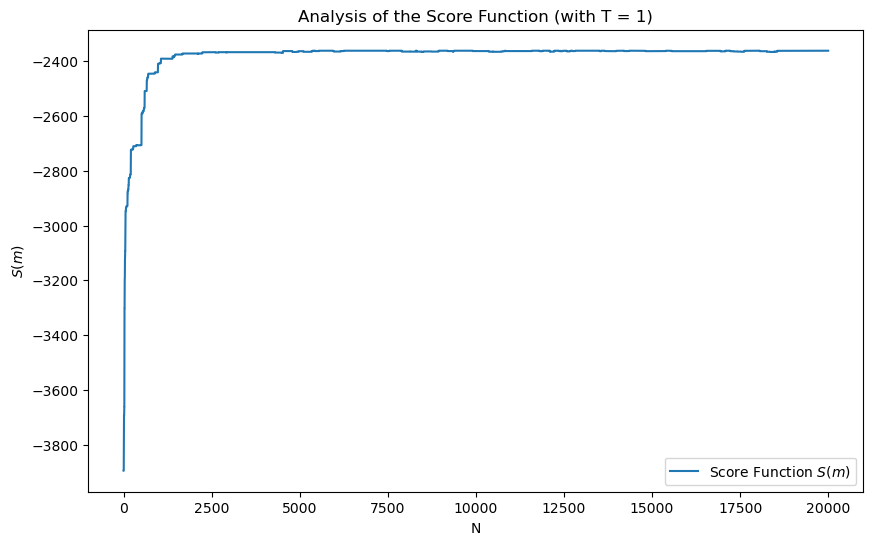

In [43]:
import matplotlib.pyplot as plt

#COLLECTING THE SCORE FUNCTION DATA NEEDED FOR THE GRAPHS:
y_values = score_history
x_values = list(range(len(y_values)))


text_length = len(message)

#Size of the figure
plt.figure(figsize=(10, 6))

#Plot the graph
plt.plot(x_values, y_values, label="Score Function $S(m)$")

#Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

#Show title and legend
plt.title("Analysis of the Score Function (with T = 1)")
plt.legend()
plt.show()

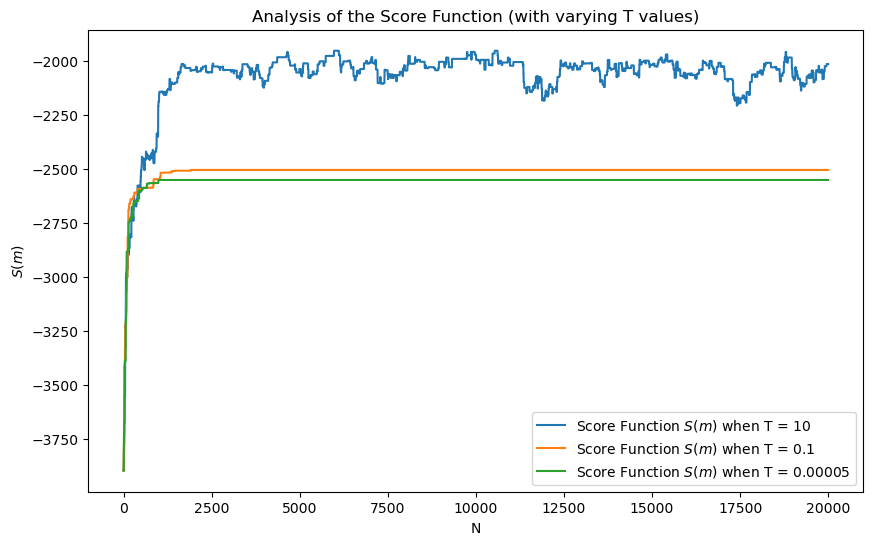

In [44]:
#NOW WE HAVE 2 COMPARISON GRAPHS:

#TEMPERATURE:
#T = 10
final_text, T10_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 10, verbose = False)
#T = 0.1
final_text, T01_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 0.1, verbose = False)
#T = SMLLEST CASE
final_text, Tsmall_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 0.00005, verbose = False)


#Size of the figure
plt.figure(figsize=(10, 6))

#Plot the graph
plt.plot(x_values, T10_score_history, label="Score Function $S(m)$ when T = 10")
plt.plot(x_values, T01_score_history, label="Score Function $S(m)$ when T = 0.1")
plt.plot(x_values, Tsmall_score_history, label="Score Function $S(m)$ when T = 0.00005")

#Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

#Show title and legend
plt.title("Analysis of the Score Function (with varying T values)")
plt.legend()
plt.show()

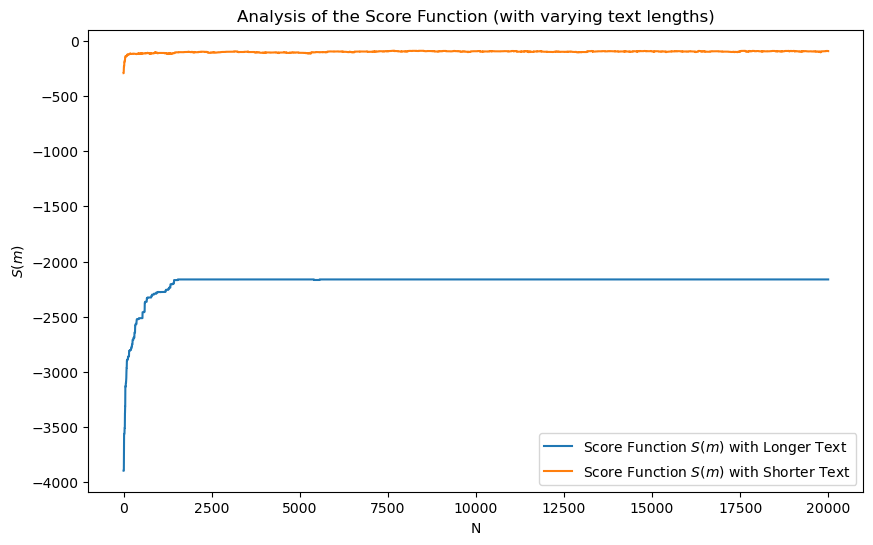

In [45]:
#LENGTH (Setting the Temperature back to T = 1):
#LONG TEXT
final_text, long_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = False)
#SHORT
#IMPORTING OUR SEVENTH CODED MESSAGE
notebook_path = 'CodedMessages.ipynb'
cell_index = 6

try:
    with open(notebook_path, 'r', encoding = 'utf-8') as f:
        nb = nbformat.read(f, as_version = 4)

    cell = nb.cells[cell_index]

    short_message = cell.source

except FileNotFoundError:
    print('Could not find file.')
except IndexError:
    print('Indexing Error.')

final_text, short_score_history = metropolis(short_message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = False)


#Size of the figure
plt.figure(figsize=(10, 6))

#Plot the graph
plt.plot(x_values, long_score_history, label="Score Function $S(m)$ with Longer Text")
plt.plot(x_values, short_score_history, label="Score Function $S(m)$ with Shorter Text")

#Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

#Show title and legend
plt.title("Analysis of the Score Function (with varying text lengths)")
plt.legend()
plt.show()

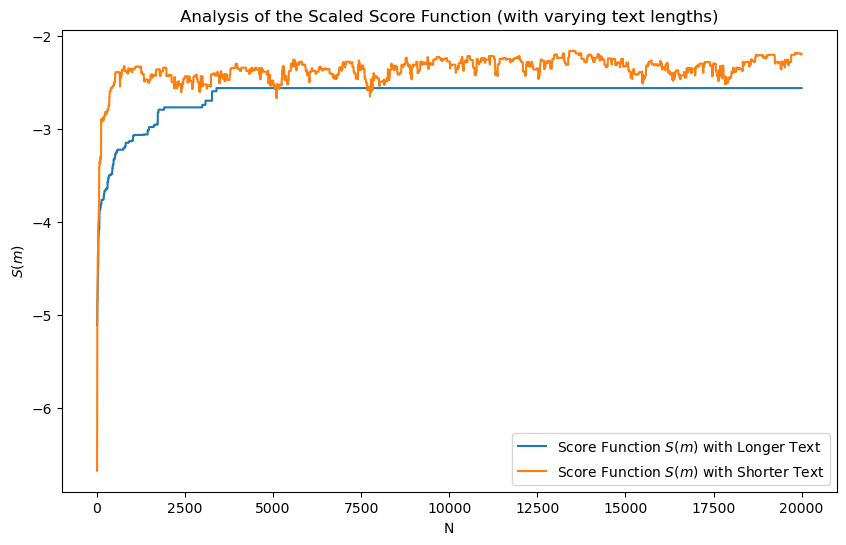

In [46]:
#Since the Score Function for the shorter text plots a graph with a greater score value compared to the long text, we need to adjust the scaling for these values:
plt.figure(figsize=(10, 6))

#LENGTH (Setting the Temperature back to T = 1):
#LONG TEXT
final_text, long_score_history = metropolis(message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = False)

normalized_long = [score / len(message) for score in long_score_history]
plt.plot(normalized_long, label="Score Function $S(m)$ with Longer Text")

#SHORT
final_text, short_score_history = metropolis(short_message, character_list, all_bigram_freqs_dicts, 20000, 1, verbose = False)

normalized_short = [score / len(short_message) for score in short_score_history]
plt.plot(normalized_short, label="Score Function $S(m)$ with Shorter Text")


#Label the axes
plt.xlabel("N")
plt.ylabel("$S(m)$")

#Show title and legend
plt.title("Analysis of the Scaled Score Function (with varying text lengths)")
plt.legend()
plt.show()